<a href="https://colab.research.google.com/github/rounak393/clab/blob/main/types_of_u_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import cv2
import warnings
import torch.nn.functional as F
from torchinfo import summary
from torchvision.models import resnet34, ResNet34_Weights

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
BASE_DIR = "/kaggle/input/datasets/britikak/busi-dataset/Dataset_BUSI_with_GT"

CLASSES = ["benign", "malignant"]

IMG_SIZE = 256
BATCH_SIZE = 8
SEED = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

class BUSISegmentationDataset(Dataset):
    def __init__(self, base_dir, classes, transform=None):
        self.samples = []
        self.transform = transform

        for cls in classes:
            cls_dir = os.path.join(base_dir, cls)

            images = [
                f for f in os.listdir(cls_dir)
                if f.endswith(".png") and "_mask" not in f
            ]

            for img_name in images:
                img_path = os.path.join(cls_dir, img_name)
                base_name = img_name.replace(".png", "")

                mask_files = [
                    f for f in os.listdir(cls_dir)
                    if f.startswith(base_name + "_mask") and f.endswith(".png")
                ]

                if len(mask_files) == 0:
                    continue

                mask_paths = [os.path.join(cls_dir, f) for f in mask_files]
                self.samples.append((img_path, mask_paths))

        assert len(self.samples) > 0, "No valid image-mask pairs found!"

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_paths = self.samples[idx]

        image = np.array(Image.open(img_path).convert("RGB"))

        combined_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        for mpath in mask_paths:
            mask = np.array(Image.open(mpath).convert("L"))
            mask = (mask > 0).astype(np.uint8)
            combined_mask = np.logical_or(combined_mask, mask)

        combined_mask = combined_mask.astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=combined_mask)
            image = augmented["image"]
            combined_mask = augmented["mask"]

        # Ensure binary mask (important!)
        combined_mask = (combined_mask > 0.5).astype(np.float32)

        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(combined_mask).unsqueeze(0).float()

        return image, mask

# ===================---------------------=======================
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0)
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0)
])

test_transform = val_transform

# ===================------------------------==================
full_dataset = BUSISegmentationDataset(BASE_DIR, classes=CLASSES, transform=None)


total_size = len(full_dataset)
indices = list(range(total_size))

np.random.seed(SEED)
np.random.shuffle(indices)


train_size = int(0.8 * total_size)
val_size   = int(0.1 * total_size)

val_indices = indices[:val_size]
train_indices   = indices[val_size:train_size + val_size]
test_indices  = indices[train_size + val_size:]


train_dataset = torch.utils.data.Subset(
    BUSISegmentationDataset(BASE_DIR, CLASSES, transform=train_transform),
    train_indices
)

val_dataset = torch.utils.data.Subset(
    BUSISegmentationDataset(BASE_DIR, CLASSES, transform=val_transform),
    val_indices
)

test_dataset = torch.utils.data.Subset(
    BUSISegmentationDataset(BASE_DIR, CLASSES, transform=test_transform),
    test_indices
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [ ]:
print("Train indices (first 10):", train_indices[:10])
print("Val indices (first 10):", val_indices[:10])
print("Test indices (first 10):", test_indices[:10])

print("Train transform:")
print(train_dataset.dataset.transform)

print("\nVal transform:")
print(val_dataset.dataset.transform)

print("\nTest transform:")
print(test_dataset.dataset.transform)

Train indices (first 10): [364, 300, 350, 579, 163, 583, 65, 403, 49, 554]
Val indices (first 10): [634, 220, 426, 428, 72, 437, 181, 131, 231, 277]
Test indices (first 10): [476, 105, 565, 389, 1, 603, 561, 80, 205, 34]
Train transform:
Compose([
  Resize(p=1.0, area_for_downscale=None, height=256, interpolation=1, mask_interpolation=0, width=256),
  HorizontalFlip(p=0.5),
  RandomRotate90(p=0.5),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

Val transform:
Compose([
  Resize(p=1.0, area_for_downscale=None, height=256, interpolation=1, mask_interpolation=0, width=256),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229,

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.enc1 = DoubleConv(n_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512, 1024)
        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec4 = DoubleConv(128, 64)
        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool(c1))
        c3 = self.enc3(self.pool(c2))
        c4 = self.enc4(self.pool(c3))
        b = self.bottleneck(self.pool(c4))

        d1 = self.up1(b)
        d1 = torch.cat([d1, c4], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, c3], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, c2], dim=1)
        d3 = self.dec3(d3)

        d4 = self.up4(d3)
        d4 = torch.cat([d4, c1], dim=1)
        d4 = self.dec4(d4)

        return torch.sigmoid(self.final(d4))


if __name__ == "__main__":
    model = UNet(n_channels=3, n_classes=1)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    print("\n================= MODEL SUMMARY =================\n")
    print(summary(model, input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE)))


================= MODEL SUMMARY =================

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [8, 1, 256, 256]          --
├─DoubleConv: 1-1                        [8, 64, 256, 256]         --
│    └─Sequential: 2-1                   [8, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                  [8, 64, 256, 256]         1,792
│    │    └─BatchNorm2d: 3-2             [8, 64, 256, 256]         128
│    │    └─ReLU: 3-3                    [8, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                  [8, 64, 256, 256]         36,928
│    │    └─BatchNorm2d: 3-5             [8, 64, 256, 256]         128
│    │    └─ReLU: 3-6                    [8, 64, 256, 256]         --
├─MaxPool2d: 1-2                         [8, 64, 128, 128]         --
├─DoubleConv: 1-3                        [8, 128, 128, 128]        --
│    └─Sequential: 2-2                   [8, 128, 128, 128]        --
│    │    └─Conv2d: 3-7 

Epoch 1/100 [Val]: 100%|██████████| 8/8 [00:01<00:00,  4.61it/s]



Epoch 1/100
Train Loss: 0.6242 | Val Loss: 0.5586
Train Dice: 0.2131 | Val Dice: 0.2877
Train IoU : 0.2163 | Val IoU : 0.3161
✓ Best model saved (Epoch 1, Val Loss 0.5586)


Epoch 2/100 [Val]: 100%|██████████| 8/8 [00:01<00:00,  5.36it/s]



Epoch 2/100
Train Loss: 0.5277 | Val Loss: 0.5406
Train Dice: 0.2915 | Val Dice: 0.3132
Train IoU : 0.3464 | Val IoU : 0.3356
✓ Best model saved (Epoch 2, Val Loss 0.5406)


Epoch 3/100 [Val]: 100%|██████████| 8/8 [00:01<00:00,  5.23it/s]


...


Epoch 98/100
Train Loss: 0.1188 | Val Loss: 0.2292
Train Dice: 0.8460 | Val Dice: 0.7093
Train IoU : 0.7674 | Val IoU : 0.5779


Epoch 99/100 [Val]: 100%|██████████| 8/8 [00:01<00:00,  5.14it/s]



Epoch 99/100
Train Loss: 0.1213 | Val Loss: 0.2092
Train Dice: 0.8401 | Val Dice: 0.7327
Train IoU : 0.7636 | Val IoU : 0.6079


Epoch 100/100 [Val]: 100%|██████████| 8/8 [00:01<00:00,  5.19it/s]



Epoch 100/100
Train Loss: 0.1239 | Val Loss: 0.2265
Train Dice: 0.8403 | Val Dice: 0.7123
Train IoU : 0.7591 | Val IoU : 0.5799

Training Completed!
Best Epoch: 83
Best Val Loss: 0.2023


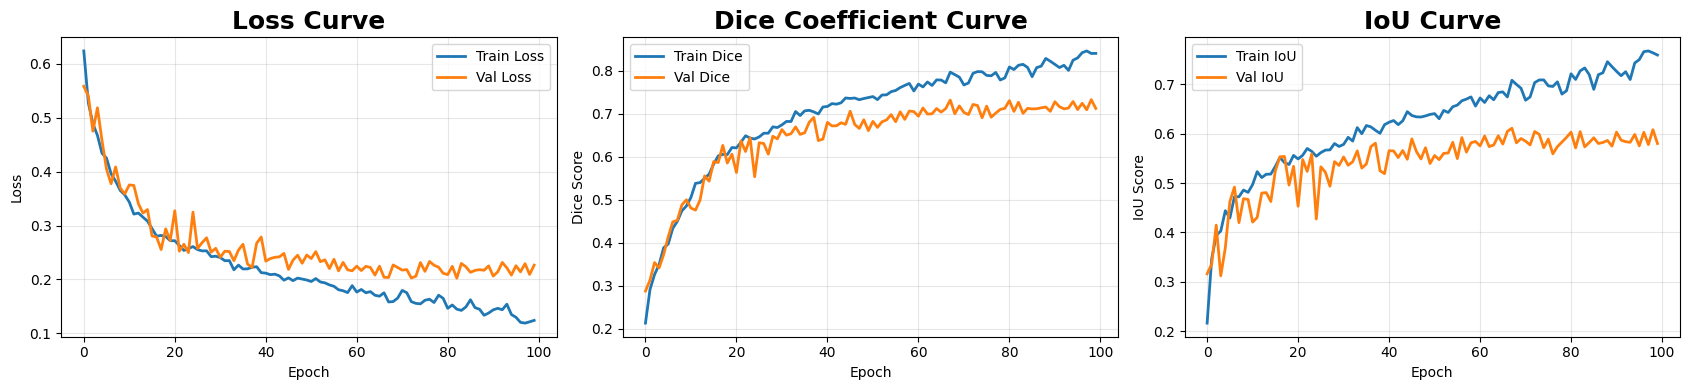

In [ ]:
from tqdm import tqdm
import copy

class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCELoss()

    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)

        preds_f = preds.view(-1)
        targets_f = targets.view(-1)
        inter = (preds_f * targets_f).sum()
        dice_loss = 1 - (2 * inter + self.smooth) / \
                        (preds_f.sum() + targets_f.sum() + self.smooth)

        return 0.5 * bce_loss + 0.5 * dice_loss



# Dice Metric
def dice_coef(y_true, y_pred, smooth=1e-5):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    inter = (y_true_f * y_pred_f).sum()
    return (2. * inter + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)


# IoU Metric
def iou_score(preds, masks, threshold=0.5, eps=1e-6):
    preds_bin = (preds > threshold).float()
    masks_bin = (masks > threshold).float()

    inter = (preds_bin * masks_bin).sum().item()
    union = preds_bin.sum().item() + masks_bin.sum().item() - inter

    return inter / (union + eps)


def train_model(model, train_loader, val_loader, epochs=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    criterion = BCEDiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',          # because we monitor val_loss
        factor=0.5,          # reduce LR by half
        patience=10,          # wait 10 epochs before reducing,
        min_lr=1e-6
    )
    # Tracking curves
    train_losses, val_losses = [], []
    train_dice_scores, val_dice_scores = [], []
    train_iou_scores, val_iou_scores = [], []

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_weights = None

    for epoch in range(epochs):
        model.train()
        train_loss = train_dice = train_iou = 0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulate
            train_loss += loss.item()
            train_dice += dice_coef(masks, preds).item()
            train_iou += iou_score(preds, masks)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = val_dice = val_iou = 0

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images, masks = images.to(device), masks.to(device)

                preds = model(images)
                val_loss += criterion(preds, masks).item()
                val_dice += dice_coef(masks, preds).item()
                val_iou += iou_score(preds, masks)

        # ------------------ AVERAGES ------------------
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss / len(val_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_val_dice   = val_dice / len(val_loader)
        avg_train_iou  = train_iou / len(train_loader)
        avg_val_iou    = val_iou / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_dice_scores.append(avg_train_dice)
        val_dice_scores.append(avg_val_dice)
        train_iou_scores.append(avg_train_iou)
        val_iou_scores.append(avg_val_iou)

        # ------------------ PRINT ------------------
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f}")
        print(f"Train IoU : {avg_train_iou:.4f} | Val IoU : {avg_val_iou:.4f}")

        # ------------------ SAVE BEST ------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_mobilenetv2_unet_monu.pth")
            print(f"✓ Best model saved (Epoch {epoch+1}, Val Loss {best_val_loss:.4f})")

        scheduler.step(avg_val_loss)

    # ------------------ LOAD BEST MODEL ------------------
    model.load_state_dict(best_model_weights)

    print("\n" + "="*60)
    print("Training Completed!")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Val Loss: {best_val_loss:.4f}")
    print("="*60)

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_dice": train_dice_scores,
        "val_dice": val_dice_scores,
        "train_iou": train_iou_scores,
        "val_iou": val_iou_scores,
    }


def plot_training(history):
    plt.figure(figsize=(17, 4))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(history["train_losses"], label="Train Loss", linewidth=2)
    plt.plot(history["val_losses"], label="Val Loss", linewidth=2)
    plt.title("Loss Curve", fontsize=18, fontweight='bold')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Dice
    plt.subplot(1, 3, 2)
    plt.plot(history["train_dice"], label="Train Dice", linewidth=2)
    plt.plot(history["val_dice"], label="Val Dice", linewidth=2)
    plt.title("Dice Coefficient Curve", fontsize=18, fontweight='bold')
    plt.xlabel("Epoch")
    plt.ylabel("Dice Score")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # IoU
    plt.subplot(1, 3, 3)
    plt.plot(history["train_iou"], label="Train IoU", linewidth=2)
    plt.plot(history["val_iou"], label="Val IoU", linewidth=2)
    plt.title("IoU Curve", fontsize=18, fontweight='bold')
    plt.xlabel("Epoch")
    plt.ylabel("IoU Score")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=300, bbox_inches='tight')
    plt.show()


history = train_model(model, train_loader, val_loader, epochs=100)

# Plot results
plot_training(history)

Loading best model...
Evaluating on test set...


Evaluating Test Set: 100%|██████████| 9/9 [00:02<00:00,  3.75it/s]



TEST SET EVALUATION
Dice Coefficient: 0.7734
IoU (Jaccard):    0.6483

Generating visualizations...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2042701].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.

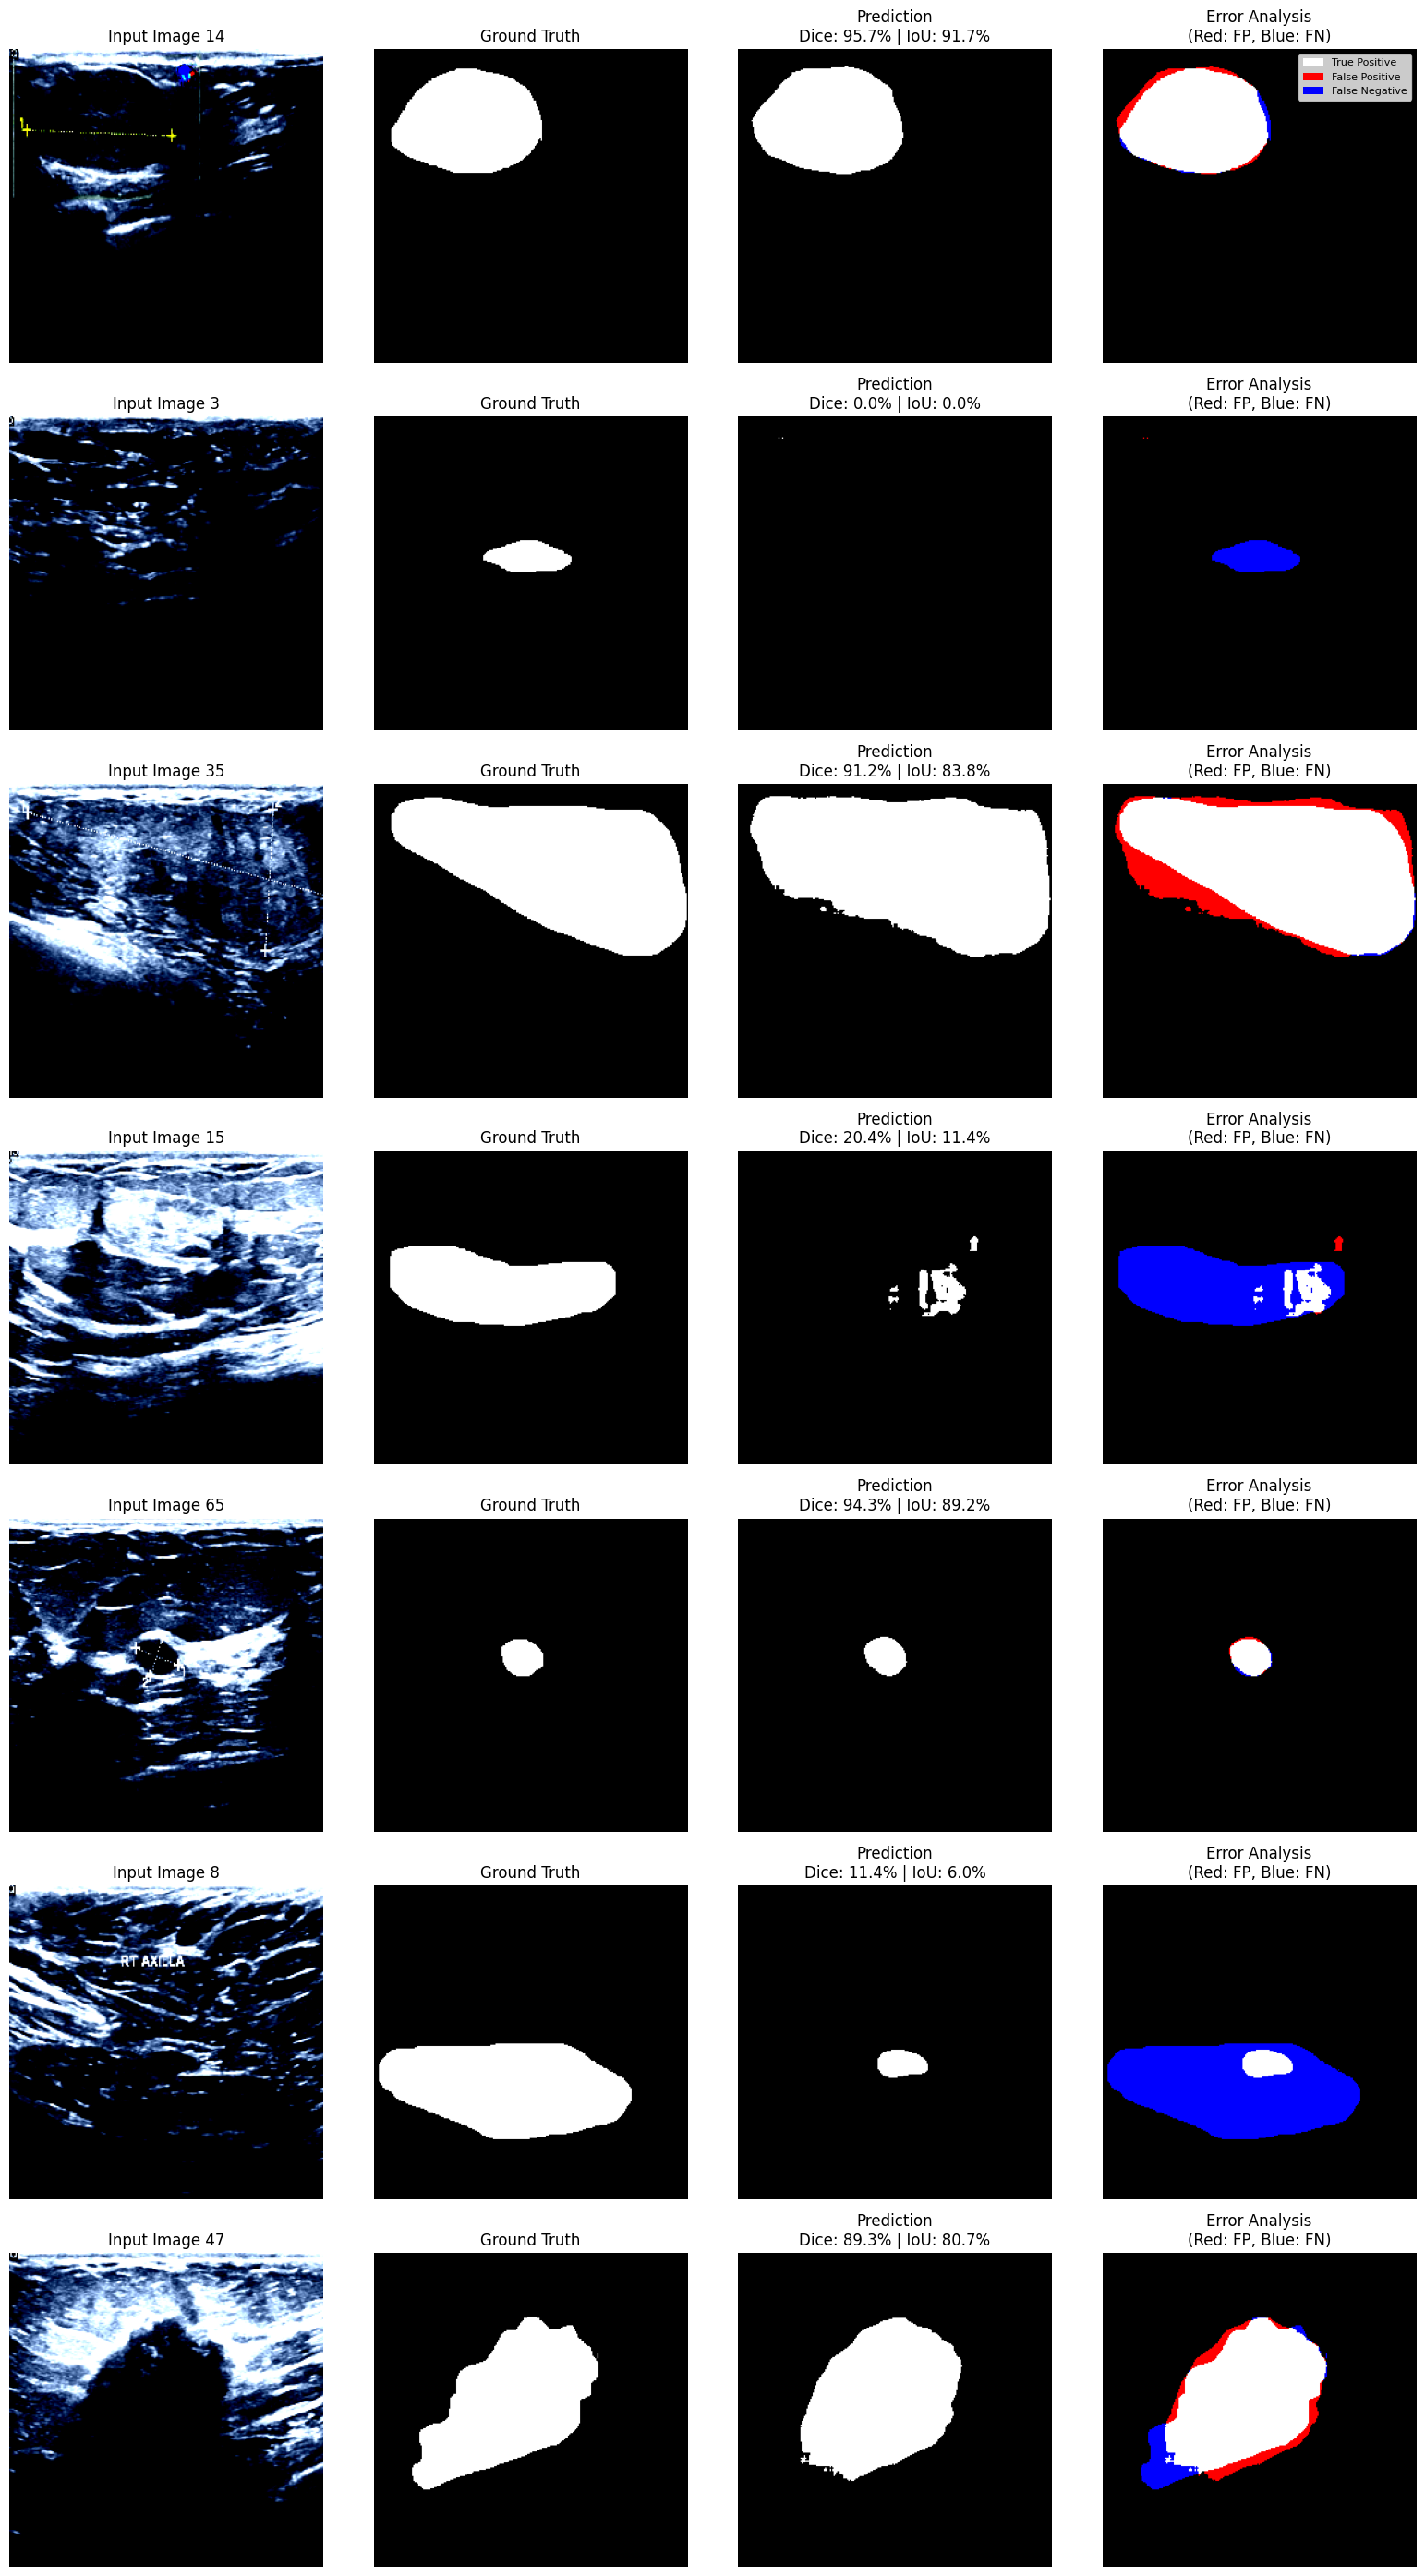


Evaluation completed successfully!


In [ ]:

def iou_coef(y_true, y_pred, smooth=1e-5):
    """
    Intersection over Union (IoU) metric for binary masks.
    """
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    intersection = (y_true_f * y_pred_f).sum()
    union = y_true_f.sum() + y_pred_f.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# Load the best model
print("Loading best model...")
model.load_state_dict(torch.load("/kaggle/working/best_mobilenetv2_unet_monu.pth", map_location=device))
model.eval()

# Initialize accumulators for metrics
test_dice, test_iou = 0, 0

print("Evaluating on test set...")

# Loop through test data
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Evaluating Test Set"):
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        preds_bin = (preds > 0.4).float()   # threshold at 0.45

        # Accumulate metrics
        test_dice += dice_coef(masks, preds_bin).item()
        test_iou += iou_coef(masks, preds_bin).item()

# Average metrics
num_batches = len(test_loader)
avg_test_dice = test_dice / num_batches
avg_test_iou = test_iou / num_batches

# Print simplified results
print("\n" + "="*40)
print("TEST SET EVALUATION")
print("="*40)
print(f"Dice Coefficient: {avg_test_dice:.4f}")
print(f"IoU (Jaccard):    {avg_test_iou:.4f}")
print("="*40)

# =============================================================
# Simplified Visualization (Only Dice and IoU)
# =============================================================

def dice_coef_single(y_true, y_pred, smooth=1e-5):
    """Compute Dice coefficient for one pair of masks"""
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def iou_coef_single(y_true, y_pred, smooth=1e-5):
    """Compute IoU for one pair of masks"""
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + smooth)

def visualize_predictions_simple(model, dataset, num_samples=5, threshold=0.5):
    """
    Simplified visualization with dice, iou and error analysis
    """
    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 4))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]

        with torch.no_grad():
            pred_prob = model(image.unsqueeze(0).to(device)).cpu().squeeze().numpy()

        pred_mask = (pred_prob > threshold).astype(np.uint8)
        true_mask = mask.squeeze().numpy().astype(np.uint8)

        # Compute metrics
        dice_score = dice_coef_single(true_mask, pred_mask) * 100
        iou_score = iou_coef_single(true_mask, pred_mask) * 100

        # Create error map (FP: red, FN: blue, TP: white, TN: black)
        error_map = np.zeros((*true_mask.shape, 3), dtype=np.uint8)
        true_positive = (true_mask == 1) & (pred_mask == 1)
        false_positive = (true_mask == 0) & (pred_mask == 1)
        false_negative = (true_mask == 1) & (pred_mask == 0)

        error_map[true_positive] = [255, 255, 255]  # White for TP
        error_map[false_positive] = [255, 0, 0]     # Red for FP
        error_map[false_negative] = [0, 0, 255]     # Blue for FN

        # Plot 1: Original Image
        axes[i, 0].imshow(image.permute(1, 2, 0) if image.shape[0] == 3 else image.squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Input Image {idx}")
        axes[i, 0].axis("off")

        # Plot 2: Ground Truth
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        # Plot 3: Predicted Mask
        axes[i, 2].imshow(pred_mask, cmap="gray")
        axes[i, 2].set_title(f"Prediction\nDice: {dice_score:.1f}% | IoU: {iou_score:.1f}%")
        axes[i, 2].axis("off")

        # Plot 4: Error Analysis
        axes[i, 3].imshow(error_map)
        axes[i, 3].set_title("Error Analysis\n(Red: FP, Blue: FN)")
        axes[i, 3].axis("off")

        # Add legend for error map (only for first row)
        if i == 0:
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='white', label='True Positive'),
                Patch(facecolor='red', label='False Positive'),
                Patch(facecolor='blue', label='False Negative')
            ]
            axes[i, 3].legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

    return indices

# Run simplified visualization
print("\nGenerating visualizations...")
sampled_indices = visualize_predictions_simple(model, test_dataset, num_samples=7)

print("\nEvaluation completed successfully!")